## Exploring predictions

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import sys
import gc
import random
import importlib as imp
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import silence_tensorflow
import seaborn as sns
import rasterio
from rasterio.windows import Window

import experiment_settings
import build_model
import plots
import build_data
import read_landsat
import methods
import methods
import predictions
import read_landsat

from sklearn.metrics import mean_squared_error, mean_absolute_error

In [2]:
print(f"python version = {sys.version}")
print(f"numpy version = {np.__version__}")
print(f"tensorflow version = {tf.__version__}")  

# tf.config.set_visible_devices([], "GPU")  # turn-off tensorflow-metal if it is on
print(tf.config.list_physical_devices('GPU'))

python version = 3.10.10 | packaged by conda-forge | (main, Mar 24 2023, 20:12:31) [Clang 14.0.6 ]
numpy version = 1.23.2
tensorflow version = 2.10.0
[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# GET SETTINGS
EXP_NAME = "exp1"
REWRITE = False

settings = experiment_settings.get_settings(EXP_NAME)
settings["mode"] = "inference"

directory_paths = methods.get_directories()
SAVE_MODEL_DIRECTORY = directory_paths["save_model_dir"]
DATA_DIRECTORY = directory_paths["data_dir"]
FIGURE_DIRECTORY = directory_paths["figures_dir"]
PREDICTIONS_DIRECTORY = directory_paths["predictions_dir"]
LANDSAT_DIRECTORY = directory_paths["landsat_dir"]
MOSAICS_DIRECTORY = directory_paths["mosaics_dir"]

 --- 2020---
-7.9985992898006515 34.999261784580675 71.00104342623874 107.99995503327142
(15956, 13730) (15956, 13730)
(1684571,) (1684571,)


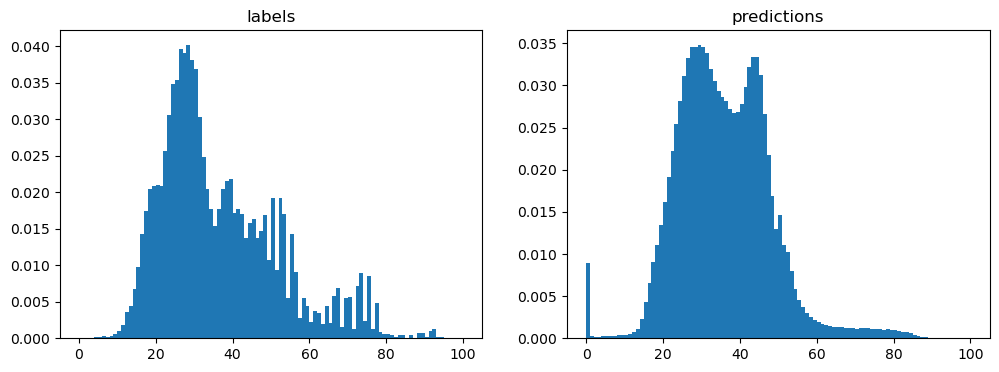

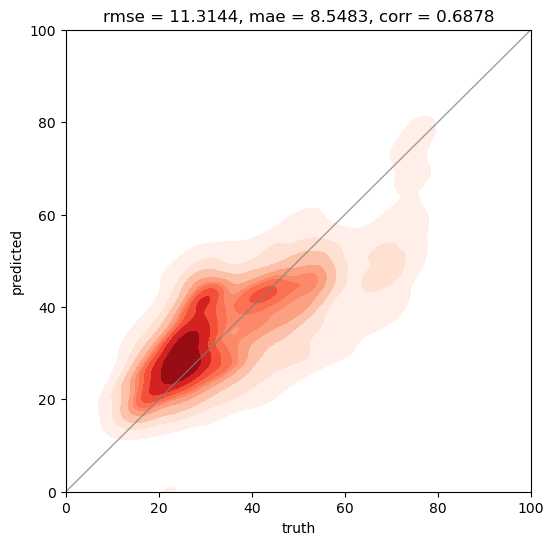

In [5]:
# GET THE DATA
imp.reload(build_data)
imp.reload(read_landsat)
imp.reload(methods)

# set and get important settings
(lat_s_bound, 
 lat_n_bound, 
 lon_w_bound, 
 lon_e_bound) = read_landsat.get_landsat_bounds(settings, 
                                                region=settings["inference_region"])

# load the model

for year in (2020,):  

    print(' --- ' + str(year) + '---')
    settings["inference_years"] = (year, )

    # TILE THE PREDICTIONS TOGETHER
    mosaic_filename = (MOSAICS_DIRECTORY + settings["exp_name"] 
                        + "_" + str(settings["inference_years"][0]) 
                        + "_mlhfi_mosaic.tif")
    labels_filename = (
        DATA_DIRECTORY 
        + "hii_" + str(settings["inference_years"][0]) + "-01-01_uint8.tif")
    
    with rasterio.open(mosaic_filename) as predict_tif:
        predictions = np.asarray(predict_tif.read(1), dtype="float")
        # print(predict_tif.xy(0,0, offset="ul"))
        # print(predict_tif.xy(predict_tif.height - 1, predict_tif.width - 1, offset="ul"))
        
        with rasterio.open(labels_filename) as label_tif:
            
            lon_w, lat_n = predict_tif.xy(0,0, offset="ul")
            lon_e, lat_s = predict_tif.xy(predict_tif.height - 1, predict_tif.width - 1, offset="ul")

            ilat_n, ilon_w = label_tif.index(lon_w, lat_n)
            ilat_s, ilon_e = label_tif.index(lon_e, lat_s)
            print(lat_s, lat_n, lon_w, lon_e)

            window = Window.from_slices((ilat_n, ilat_s + 1), (ilon_w, ilon_e + 1))
            labels = np.asarray(label_tif.read(1, window=window), dtype="float")

    print(predictions.shape, labels.shape)

    # REMOVE EDGES FOR NOW
    predictions = predictions[7:-7, 7:-7]
    labels = labels[7:-7, 7:-7]

    predictions = predictions.flatten()
    labels = labels.flatten()
    predictions, labels = methods.remove_nodata(predictions, labels)

    print(labels.shape, predictions.shape)

    # MAKE HISTOGRAMS
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    bins = np.arange(0,101,1)
    plt.hist(labels, bins, density=True)
    plt.title("labels")

    plt.subplot(1,2,2)
    bins = np.arange(0,101,1)
    plt.hist(predictions, bins, density=True)
    plt.title("predictions")

    plt.show()

    # MAKE SUMMARY FIGURE
    rng = np.random.default_rng(35)
    iplot = rng.choice(np.arange(len(predictions)), size=5_000)

    rmse = np.sqrt(mean_squared_error(labels, predictions)).round(4)
    mae = mean_absolute_error(labels, predictions).round(4)
    corr = np.corrcoef(labels, predictions)[0,1].round(4)

    plt.figure(figsize=(6,6))
    sns.kdeplot(x=labels[iplot], y=predictions[iplot], fill=True, cmap="Reds", bw_adjust=.75)
    # plt.plot(labels + np.random.uniform(size=labels.shape[0]), predictions, '.', color="gray", markersize=5, alpha=.1)
    plt.plot((0,100), (0,100), '-', linewidth=1, color="gray", alpha=.75)
    plt.title(f'{rmse = }, {mae = }, {corr = }')
    plt.xlabel('truth')
    plt.ylabel('predicted')
    plt.xlim(0,100)
    plt.ylim(0,100)
    plt.show()    

    

    